**5.Fine Tuning**

**Unfreeze the top layers of VGG16 and retrain them along with the classifier.**

**This allows the network to adapt to the dataset.**

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 319ms/step - accuracy: 0.2563 - loss: 1.8026 - val_accuracy: 0.6952 - val_loss: 1.1723
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 300ms/step - accuracy: 0.5663 - loss: 1.1826 - val_accuracy: 0.7497 - val_loss: 0.9000
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 299ms/step - accuracy: 0.6630 - loss: 0.9480 - val_accuracy: 0.7643 - val_loss: 0.7649
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 299ms/step - accuracy: 0.7007 - loss: 0.8342 - val_accuracy: 0.7783 - val_loss: 0.6827
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 303ms/step - accuracy: 0.7250 - loss: 0.7582 - val_accuracy: 0.7868 - val_loss: 0.6383
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 53s 301ms/step - accuracy: 0.7277 - loss: 0.7262 - val_accuracy: 0.7996 - val_loss: 0.6020
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━

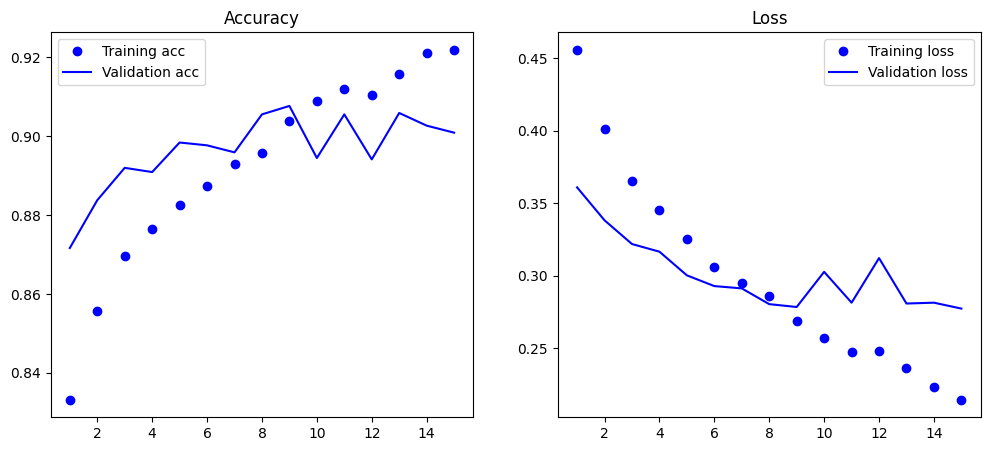

In [2]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
# Dataset paths
#train_dir = "/content/drive/MyDrive/Colab Notebooks/DL/assignment/seg_train/seg_train"
#validation_dir = "/content/drive/MyDrive/Colab Notebooks/DL/assignment/seg_test/seg_test"

train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

# GPU optimization
#mixed_precision.set_global_policy('mixed_float16')

# Load VGG16 base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)   # ⚡ faster
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # changed
)

# Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

# Build model (better than Flatten)
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Freeze base initially
conv_base.trainable = False

# Compile (initial training)
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train top layers
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)

# Fine-tuning (unfreeze last layers)
conv_base.trainable = True

for layer in conv_base.layers[:-4]:   # keep most frozen
    layer.trainable = False

# Recompile with lower LR
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)

# Save model
#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_finetuned.keras")

# Plot results
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()